# Reading a stack of rasters with `DatasetCollection`

A `DatasetCollection` is a time-series of co-registered rasters (same grid, CRS and cell size) stacked into a
single object you can index, summarise and animate. This tutorial walks through the two-step read workflow on ten
daily discharge (`Qtot`) GeoTIFFs of the Rhine basin, and then animates the resulting stack.

The cell below imports `DatasetCollection` together with the `HTML` helper used to embed the final animation in the
notebook.

In [1]:
# NBVAL_IGNORE_OUTPUT
from cleopatra.array_glyph import FrameLabel
from IPython.display import HTML

from pyramids.dataset import DatasetCollection

%matplotlib inline

2026-07-25 15:51:37 | INFO | pyramids.base.config | Logging is configured.


# Read multiple files

Reading multiple files is being done on two steps
- First use the `read_multiple_files` method to parse files names and construct the array that will later have the
values
- Second use the `open_multi_dataset` method to open all the raster files and read a specific band from each file

# read_multiple_files

The given path points to a directory where all the raster we want to read exists
The content of the directory is as following


In [2]:
# NBVAL_IGNORE_OUTPUT
import os

path = r"../../../examples/data/geotiff/rhine"
os.listdir(path)

['Qtot_1979-01-08.tif',
 'Qtot_1979-01-03.tif',
 'Qtot_1979-01-02.tif',
 'Qtot_1979-01-05.tif',
 'Qtot_1979-01-07.tif',
 'Qtot_1979-01-01.tif',
 'Qtot_1979-01-06.tif',
 'Qtot_1979-01-10.tif',
 'Qtot_1979-01-09.tif',
 'Qtot_1979-01-04.tif']

We need raster names to follow a certain pattern in order to be able to read them with a certain order, in our case
there is a date in the file name and using this date we will read the rasters and assign the values of each one in
the right location in the array based on their date

### Regex pattern

the parameter `regex_string` accepts any regex string and apply it to all file names to extract the string that is
needed to order the files, this string can be an integer or a date
here are some examples for how the `regex_string` should look like for different file names

>>> fname = "MSWEP_YYYY.MM.DD.tif"
>>> regex_string = r"\d{4}.\d{2}.\d{2}"
- or
>>> fname = "MSWEP_YYYY_M_D.tif"
>>> regex_string = r"\d{4}_\d{1}_\d{1}"
- if there is a number at the beginning of the name
>>> fname = "1_MSWEP_YYYY_M_D.tif"
>>> regex_string = r"\d+"

In [3]:
m_dataset = DatasetCollection.read_multiple_files(
    path,
    with_order=True,
    regex_string=r"\d{4}-\d{2}-\d{2}",
    date=True,
    file_name_data_fmt="%Y-%m-%d",
)

Now the `DatasetCollection` object is created; we can inspect it by printing it.

In [4]:
print(m_dataset)


            Files: 10
            Cell size: 5000.0
            EPSG: 4647
            Dimension: 125 * 93
            Mask: 2147483647.0
        


The summary confirms the stack: **10** files were parsed into a single collection over a `125 x 93` grid at a
`5000 m` cell size in EPSG:4647, sharing a no-data (`Mask`) value of `2147483647`. So far only the file names have
been parsed and ordered by date - no pixel values have been read into memory yet. That happens in the next step.

# open_multi_dataset

To read a specific band from each file and assign it to its location in the array we can pass the band index to the
`open_multi_dataset` method, (the default band value is 0)

In [5]:
m_dataset.open_multi_dataset()

After loading, `values` is the `(time, rows, cols)` NumPy array holding every timestep. We print it to confirm the
pixels are now in memory.

In [6]:
# NBVAL_IGNORE_OUTPUT
print(m_dataset.values)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


The printed corners are all `0` because the Rhine basin covers only part of the rectangular grid - the surrounding
cells are background/no-data. The non-zero discharge values sit in the interior, which the animation below brings
out.

# plot

To animate the collection, call `plot`. The key parameters control which cells are drawn and how values map to
colour:

| parameter | value | meaning |
|-----------|-------|---------|
| `exclude_value` | `0` | treat `0` as background so those cells stay blank |
| `frame_label` | `FrameLabel(location=(1, 3))` | where the per-frame label is drawn |
| `color_scale` | `"linear"` | linear mapping of value to colour |
| `vmin`, `vmax` | `1`, `100` | clip the colour range to 1-100 discharge units |

`plot` returns a cleopatra glyph whose `.anim` attribute holds the Matplotlib animation.


                    Min: 1.0
                    Max: 3375.0
                    Exclude values: [2147483647.0, 0]
                    RGB: False
                


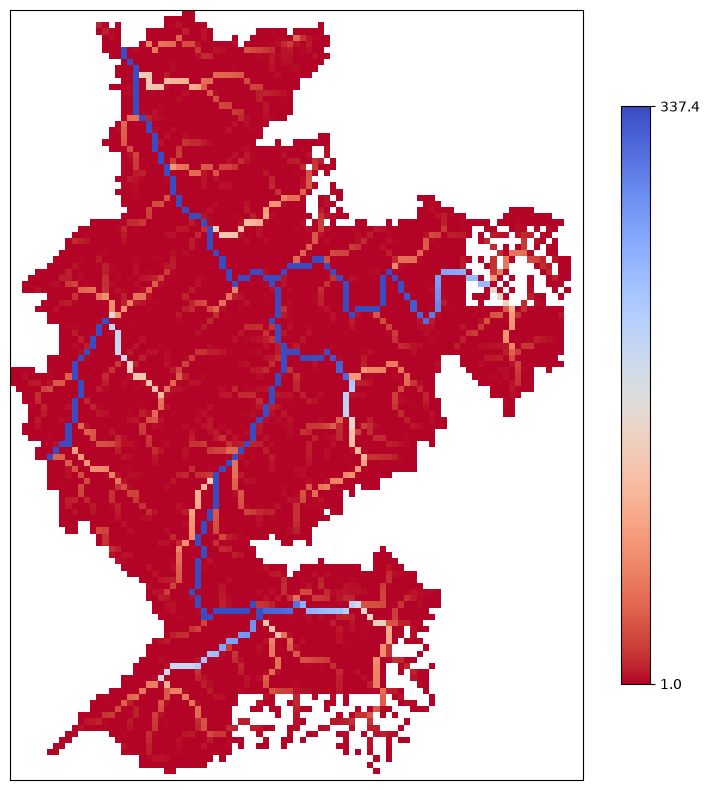

In [7]:
# NBVAL_IGNORE_OUTPUT
cleo = m_dataset.plot(
    exclude_value=0,
    frame_label=FrameLabel(location=(1, 3)),
    color_scale="linear",
    vmin=1,
    vmax=100,
)
print(cleo)

In [8]:
# NBVAL_IGNORE_OUTPUT
HTML(cleo.anim.to_jshtml())

Each frame is one day of the `Qtot` series: the coloured cells trace discharge across the Rhine basin while the
excluded background stays blank, so the ten-day evolution reads as a smooth time-lapse. The returned glyph also
exposes the underlying Matplotlib figure/axes if you want to restyle the frames.